# EFIplus Mediterranean Dataset — Linear Regression Exercise

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/FernandaChacara/PML/blob/main/code-scripts/EFIplus_medit_regression_notebook.ipynb)

This notebook answers the assignment using the dataset `EFIplus_medit.zip`.

The analysis has three parts:

1. Simple linear regressions between species richness and each continuous environmental variable.
2. Multiple linear regression using all predictors and comparison with the univariate coefficients.
3. Multicollinearity diagnosis and a second, more parsimonious regression model.

## Environmental predictors used

The predictors required by the assignment are:

- `Altitude`
- `Actual_river_slope`
- `Elevation_mean_catch`
- `prec_ann_catch`
- `temp_ann`
- `temp_jan`
- `temp_jul`

The response variable is **species richness**.

In [30]:

import os
import zipfile
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.linear_model import LinearRegression
from sklearn.inspection import PartialDependenceDisplay

from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

# 1. Load the dataset

This notebook expects `EFIplus_medit.zip` to be in the working directory.

In Colab, upload the ZIP file using the file panel on the left. In VS Code, place the ZIP file in the same folder as this notebook.

In [34]:
from google.colab import files

uploaded = files.upload()

Saving EFIplus_medit (2).zip to EFIplus_medit (2) (1).zip


In [35]:
zip_path = "EFIplus_medit (2).zip"
extract_folder = "EFIplus_medit"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_folder)

csv_file = "EFIplus_medit/EFIplus_medit.csv"

df = pd.read_csv(csv_file, sep=";")

df.head()


,Site_code,Latitude,Longitude,Country,Catchment_name,Galiza,Subsample,Calib_EFI_Medit,Calib_connect,Calib_hydrol,Calib_morphol,Calib_wqual,Geomorph1,Geomorph2,Geomorph3,Water_source_type,Flow_regime,Altitude,Geological_typology,Actual_river_slope,Natural_sediment,Elevation_mean_catch,prec_ann_catch,temp_ann,temp_jan,temp_jul,Barriers_catchment_down,Barriers_river_segment_up,Barriers_river_segment_down,Barriers_number_river_segment_up,Barriers_number_river_segment_down,Barriers_distance_river_segment_up,Barriers_distance_river_segment_down,Impoundment,Hydropeaking,Water_abstraction,Hydro_mod,Temperature_impact,Velocity_increase,Reservoir_flushing,Sedimentation,Channelisation,Cross_sec,Instream_habitat,Riparian_vegetation,Embankment,Floodprotection,Floodplain,Toxic_substances,Acidification,...,Leuciscus leuciscus,Leuciscus lucumonis,Leuciscus souffia,Liza aurata,Liza ramada,Luciobarbus guiraonis,Micropterus salmoides,Mugil cephalus,Oncorhynchus mykiss,Pachychilon pictum,Padogobius martensii,Padogobius nigricans,Parachondrostoma arrigonis,Parachondrostoma miegii,Parachondrostoma turiense,Perca fluviatilis,Petromyzon marinus,Phoxinus bigerri,Phoxinus phoxinus,Platichthys flesus,Pseudochondrostoma duriense,Pseudochondrostoma polylepis,Pseudochondrostoma willkommii,Pseudorasbora parva,Rhodeus amarus,Rutilus aula,Rutilus rubilio,Rutilus rutilus,Salaria fluviatilis,Salmo salar,Salmo trutta fario,Salmo trutta macrostigma,Salvelinus fontinalis,Sander lucioperca,Scardinius erythrophthalmus,Silurus glanis,Squalius alburnoides,Squalius aradensis,Squalius carolitertii,Squalius laietanus,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
0,ES_01_0002,38.102003,-4.096070,Spain,Guadalquivir,0,1,0,1,0,1,1,-0.047266,-1.039638,0.451016,Pluvial,Permanent,199,Siliceous,0.001,3.0,700.840807,522.071164,17.6,8.5,28.1,3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,5.0,1.0,1.0,1.0,1,4.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,1.0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,ES_02_0001,40.530188,-1.887796,Spain,Tejo,0,1,1,1,1,1,1,0.389648,-0.443332,0.489422,Groundwater,Permanent,1253,Calcareous,13.406,3.0,1603.519424,640.327779,9.3,0.6,18.9,3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1,1.0,1.0,1.0,1.0,2.0,1.0,1.0,NaN,1.0,1.0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,ES_02_0002,40.595432,-1.928079,Spain,Tejo,0,1,1,1,1,1,1,0.344331,-0.504929,0.485476,Groundwater,Permanent,1155,Calcareous,9.398,3.0,1578.678579,633.238847,10.1,1.2,19.6,3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1,1.0,1.0,1.0,1.0,2.0,1.0,1.0,NaN,1.0,1.0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,ES_02_0003,40.656184,-1.989831,Spain,Tejo,0,1,1,1,1,1,1,0.460283,-0.485457,-1.115365,Groundwater,Permanent,1074,Calcareous,8.186,3.0,1553.219128,625.841858,10.1,1.2,19.5,3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,1.0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,ES_02_0004,40.676402,-2.036274,Spain,Tejo,0,1,1,1,1,1,1,0.272000,-0.598013,0.479972,Groundwater,Permanent,1018,Calcareous,11.736,3.0,1539.684999,622.111415,10.3,1.7,20.0,3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,1.0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


# 2. Define response variable and predictors

The code tries to automatically detect the species richness column. If it fails, inspect `df.columns` and manually set the variable `response`.

In [38]:
predictors_original = [
    "Altitude",
    "Actual_river_slope",
    "Elevation_mean_catch",
    "prec_ann_catch",
    "temp_ann",
    "temp_jan",
    "temp_jul"
]

missing_predictors = [col for col in predictors_original if col not in df.columns]
if missing_predictors:
    raise ValueError(
        f"The following required predictor columns are missing: {missing_predictors}\n"
        f"Available columns are: {list(df.columns)}"
    )

# Define a list of all known non-species columns based on the dataset's structure.
# This list includes identifiers, general environmental descriptors, and other metadata.
all_known_non_species_columns = [
    "Site_code", "Latitude", "Longitude", "Country", "Catchment_name",
    "Galiza", "Subsample", "Calib_EFI_Medit", "Calib_connect", "Calib_hydrol",
    "Calib_morphol", "Calib_wqual", "Geomorph1", "Geomorph2", "Geomorph3",
    "Water_source_type", "Flow_regime", "Geological_typology", "Natural_sediment",
    "Barriers_catchment_down", "Barriers_river_segment_up", "Barriers_river_segment_down",
    "Barriers_number_river_segment_up", "Barriers_number_river_segment_down",
    "Barriers_distance_river_segment_up", "Barriers_distance_river_segment_down",
    "Impoundment", "Hydropeaking", "Water_abstraction", "Hydro_mod",
    "Sediment_retention_index", "Temp_increase", "Temp_diff", "Runoff_coeff_catch",
    "Ichty_class", "EFI_plus_prediction", "EFI_plus_class", "Status_class",
    "Fish_species_richness" # Exclude if it's a pre-calculated richness, we will calculate our own.
]

# Add the original predictors to the list of non-species columns
all_known_non_species_columns.extend(predictors_original)

# Identify actual species columns by excluding all known non-species columns from the DataFrame's columns
species_cols = [col for col in df.columns if col not in all_known_non_species_columns]

# Calculate species richness by summing the presence (value > 0) of each species for each row
# Assuming that values in species columns represent counts or presence (1) / absence (0)
df["species_richness"] = (df[species_cols] > 0).sum(axis=1)

# Set the response variable to the newly created species richness column
response = "species_richness"

print("Response variable:", response)
print("Predictor variables:", predictors_original)


Response variable: species_richness
Predictor variables: ['Altitude', 'Actual_river_slope', 'Elevation_mean_catch', 'prec_ann_catch', 'temp_ann', 'temp_jan', 'temp_jul']


In [39]:

model_data = df[[response] + predictors_original].copy()

for col in model_data.columns:
    model_data[col] = pd.to_numeric(model_data[col], errors="coerce")

print("Missing values before dropping rows:")
display(model_data.isna().sum())

model_data = model_data.dropna()

print("\nShape after dropping missing values:", model_data.shape)
display(model_data.describe())

Missing values before dropping rows:


,0
species_richness,0
Altitude,0
Actual_river_slope,36
Elevation_mean_catch,170
prec_ann_catch,170
temp_ann,170
temp_jan,170
temp_jul,170



Shape after dropping missing values: (4819, 8)


,species_richness,Altitude,Actual_river_slope,Elevation_mean_catch,prec_ann_catch,temp_ann,temp_jan,temp_jul
count,4819.000000,4819.000000,4819.000000,4819.000000,4819.000000,4819.000000,4819.000000,4819.000000
mean,22.552189,429.196306,14.550648,785.722911,942.380128,13.255530,6.205707,20.595808
std,3.466067,338.590837,22.581507,432.516458,292.214393,2.170102,2.663084,2.577292
min,10.000000,0.000000,0.000000,52.249944,373.366940,3.900000,-2.700000,11.900000
25%,21.000000,150.000000,3.506000,468.772143,678.613067,12.000000,4.300000,18.700000
50%,22.000000,378.000000,8.000000,701.770707,970.437704,13.400000,6.400000,20.100000
75%,25.000000,613.500000,17.170000,1050.956735,1168.006235,14.600000,8.300000,22.500000
max,49.000000,1851.000000,774.000000,2545.546876,1739.000486,18.300000,12.500000,28.200000


# 3. Check whether transformations are needed

Before fitting the regressions, I check the distributions of the continuous predictors.

A transformation is useful when a predictor is strongly skewed. In this notebook, I use this practical rule:

- if a non-temperature predictor is non-negative and has absolute skewness greater than 1, I apply `log1p`;
- temperature variables are kept in their original units for easier interpretation.

,Variable,Min,Max,Skewness
0,Altitude,0.000000,1851.000000,0.958518
1,Actual_river_slope,0.000000,774.000000,10.559843
2,Elevation_mean_catch,52.249944,2545.546876,0.845986
3,prec_ann_catch,373.366940,1739.000486,0.057315
4,temp_ann,3.900000,18.300000,-0.474656
5,temp_jan,-2.700000,12.500000,-0.283328
6,temp_jul,11.900000,28.200000,0.287409


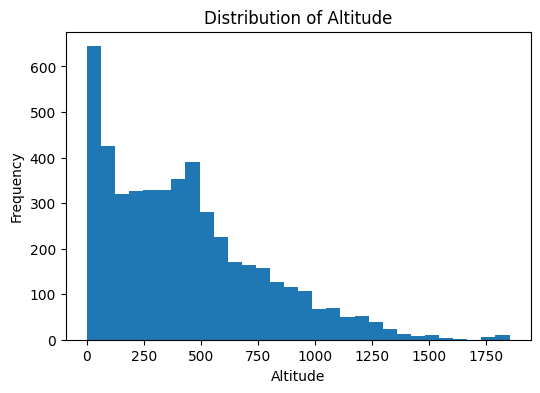

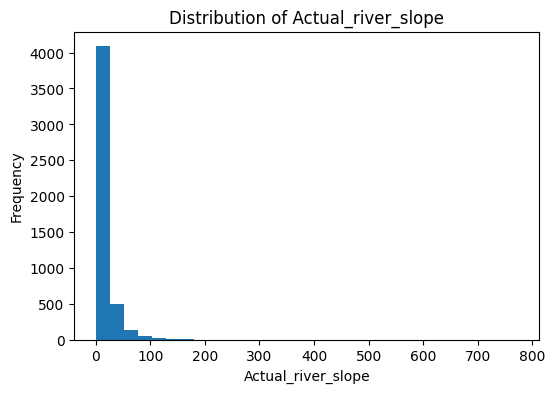

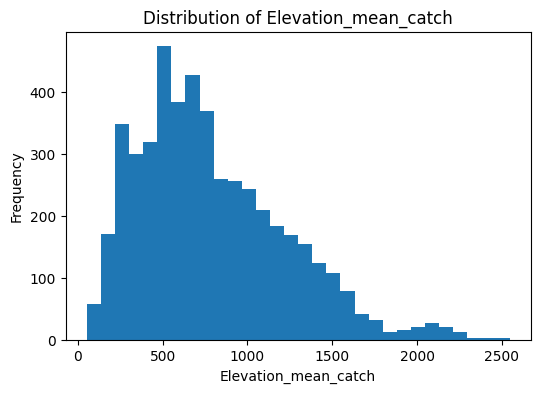

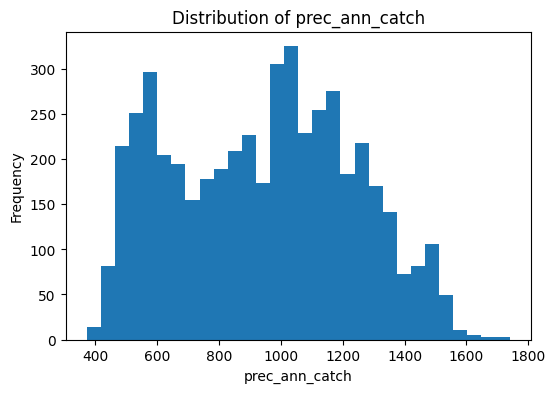

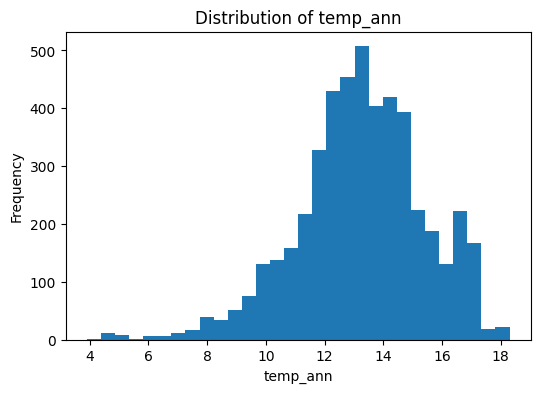

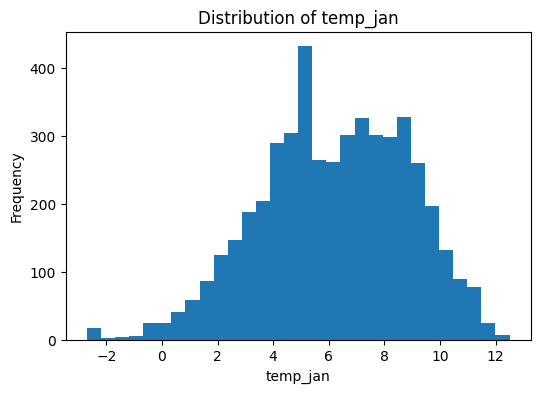

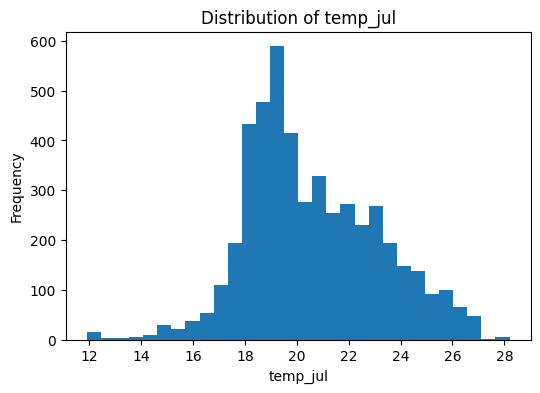

In [40]:
# prompt: Check skewness and plot predictor distributions.

skew_table = []

for var in predictors_original:
    skew_table.append({
        "Variable": var,
        "Min": model_data[var].min(),
        "Max": model_data[var].max(),
        "Skewness": model_data[var].skew()
    })

skew_df = pd.DataFrame(skew_table)
display(skew_df)

for var in predictors_original:
    plt.figure(figsize=(6, 4))
    plt.hist(model_data[var], bins=30)
    plt.title(f"Distribution of {var}")
    plt.xlabel(var)
    plt.ylabel("Frequency")
    plt.show()

In [41]:
# prompt: Apply log1p transformation to strongly skewed positive predictors.

df_reg = model_data.copy()

transformed_predictors = []
transformation_report = []

for var in predictors_original:
    skewness = df_reg[var].skew()
    min_value = df_reg[var].min()
    is_temperature = var in ["temp_ann", "temp_jan", "temp_jul"]

    if (not is_temperature) and (min_value >= 0) and (abs(skewness) > 1):
        new_var = f"log1p_{var}"
        df_reg[new_var] = np.log1p(df_reg[var])
        transformed_predictors.append(new_var)
        transformation_report.append({
            "Original variable": var,
            "Used variable": new_var,
            "Transformation": "log1p",
            "Original skewness": skewness,
            "Transformed skewness": df_reg[new_var].skew()
        })
    else:
        transformed_predictors.append(var)
        transformation_report.append({
            "Original variable": var,
            "Used variable": var,
            "Transformation": "none",
            "Original skewness": skewness,
            "Transformed skewness": skewness
        })

transformation_df = pd.DataFrame(transformation_report)

print("Variables used in the regressions:")
print(transformed_predictors)
display(transformation_df)

Variables used in the regressions:
['Altitude', 'log1p_Actual_river_slope', 'Elevation_mean_catch', 'prec_ann_catch', 'temp_ann', 'temp_jan', 'temp_jul']


,Original variable,Used variable,Transformation,Original skewness,Transformed skewness
0,Altitude,Altitude,none,0.958518,0.958518
1,Actual_river_slope,log1p_Actual_river_slope,log1p,10.559843,0.078640
2,Elevation_mean_catch,Elevation_mean_catch,none,0.845986,0.845986
3,prec_ann_catch,prec_ann_catch,none,0.057315,0.057315
4,temp_ann,temp_ann,none,-0.474656,-0.474656
5,temp_jan,temp_jan,none,-0.283328,-0.283328
6,temp_jul,temp_jul,none,0.287409,0.287409


# 4. Simple linear regressions

Each simple regression relates species richness to one environmental predictor at a time.

For each model I compute:

- coefficient estimate;
- intercept;
- R-squared;
- F-statistic;
- F-test p-value.

In [42]:

simple_results = []

for var in transformed_predictors:
    formula = f"{response} ~ Q('{var}')"
    model = smf.ols(formula, data=df_reg).fit()

    coef_name = f"Q('{var}')"
    simple_results.append({
        "Predictor": var,
        "Intercept": model.params["Intercept"],
        "Coefficient_simple": model.params[coef_name],
        "R_squared": model.rsquared,
        "F_statistic": model.fvalue,
        "F_pvalue": model.f_pvalue,
        "Coefficient_pvalue": model.pvalues[coef_name]
    })

simple_results_df = pd.DataFrame(simple_results)
display(simple_results_df)

,Predictor,Intercept,Coefficient_simple,R_squared,F_statistic,F_pvalue,Coefficient_pvalue
0,Altitude,23.942165,-0.003239,0.100087,535.741411,1.783018e-112,1.783018e-112
1,log1p_Actual_river_slope,24.862669,-1.046488,0.096210,512.779075,5.708247e-108,5.708247e-108
2,Elevation_mean_catch,24.345999,-0.002283,0.081161,425.482900,1.168090e-90,1.168090e-90
3,prec_ann_catch,22.491164,0.000065,0.000030,0.143579,7.047651e-01,7.047651e-01
4,temp_ann,16.596487,0.449299,0.079133,413.940681,2.390141e-88,2.390141e-88
5,temp_jan,20.369867,0.351664,0.073005,379.358699,2.157414e-81,2.157414e-81
6,temp_jul,17.878730,0.226913,0.028469,141.153746,4.165604e-32,4.165604e-32


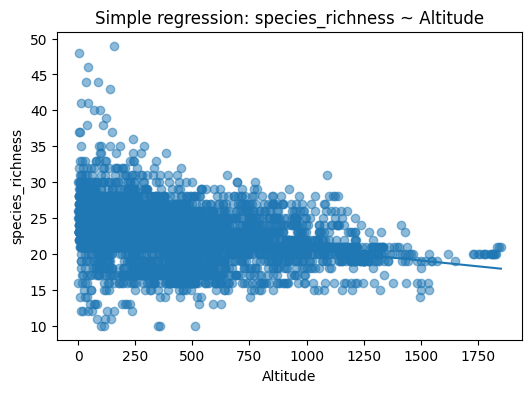

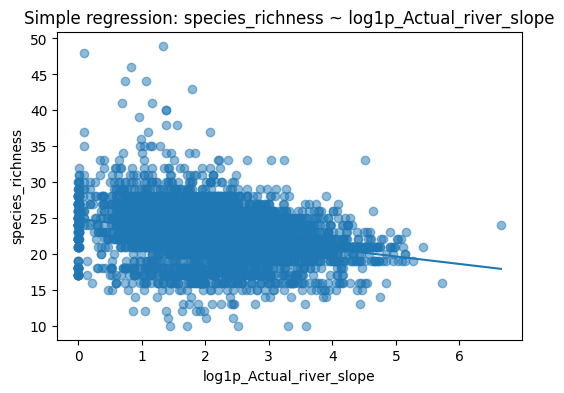

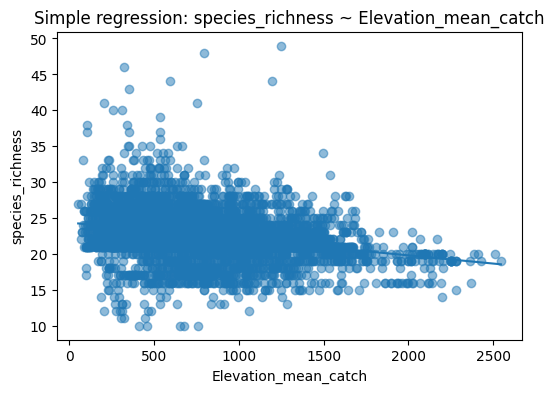

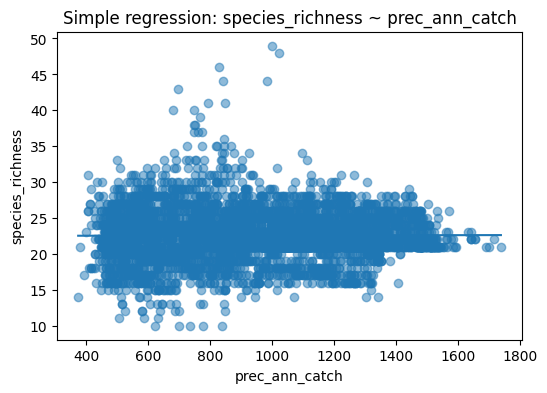

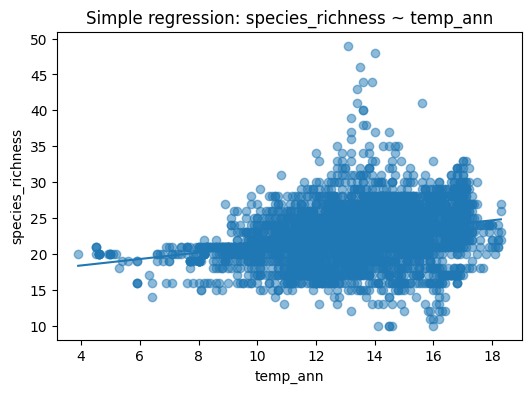

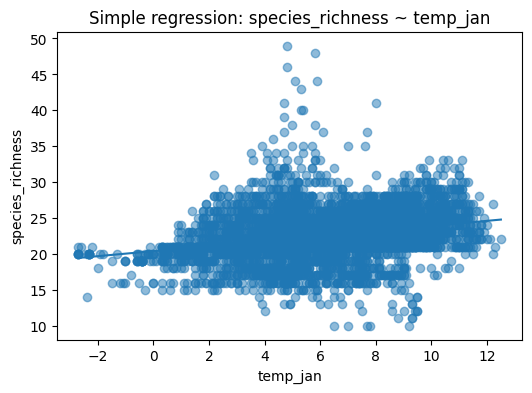

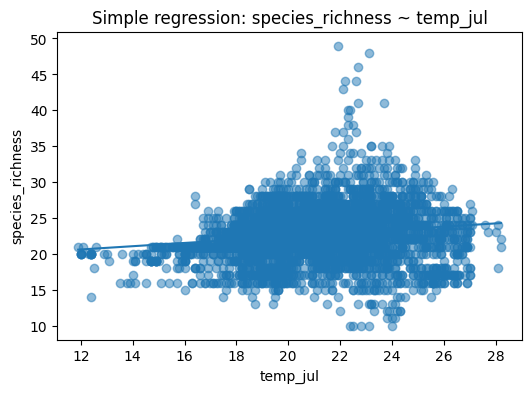

In [43]:

for var in transformed_predictors:
    model = smf.ols(f"{response} ~ Q('{var}')", data=df_reg).fit()

    x = df_reg[var]
    y = df_reg[response]

    x_grid = np.linspace(x.min(), x.max(), 100)
    y_pred = model.params["Intercept"] + model.params[f"Q('{var}')"] * x_grid

    plt.figure(figsize=(6, 4))
    plt.scatter(x, y, alpha=0.5)
    plt.plot(x_grid, y_pred)
    plt.xlabel(var)
    plt.ylabel(response)
    plt.title(f"Simple regression: {response} ~ {var}")
    plt.show()

# 5. Multiple linear regression

Now I fit a multiple linear regression with all predictors simultaneously.

In the simple regressions, each coefficient describes the isolated relationship between richness and one predictor.

In the multiple regression, each coefficient represents the effect of one predictor while controlling for all the others. Therefore, coefficients may change in magnitude, significance or even sign.

In [44]:
# prompt: Fit a multiple linear regression using all transformed environmental predictors.

formula_multiple = response + " ~ " + " + ".join([f"Q('{v}')" for v in transformed_predictors])

multiple_model = smf.ols(formula_multiple, data=df_reg).fit()

print(multiple_model.summary())

                            OLS Regression Results                            
Dep. Variable:       species_richness   R-squared:                       0.154
Model:                            OLS   Adj. R-squared:                  0.153
Method:                 Least Squares   F-statistic:                     125.2
Date:                Fri, 15 May 2026   Prob (F-statistic):          1.14e-169
Time:                        20:30:39   Log-Likelihood:                -12424.
No. Observations:                4819   AIC:                         2.486e+04
Df Residuals:                    4811   BIC:                         2.492e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

In [45]:


multiple_coefs = []

for var in transformed_predictors:
    coef_name = f"Q('{var}')"
    multiple_coefs.append({
        "Predictor": var,
        "Coefficient_multiple": multiple_model.params[coef_name],
        "Multiple_pvalue": multiple_model.pvalues[coef_name]
    })

multiple_coefs_df = pd.DataFrame(multiple_coefs)

coefficient_comparison = simple_results_df.merge(multiple_coefs_df, on="Predictor", how="left")
coefficient_comparison["Coefficient_change"] = (
    coefficient_comparison["Coefficient_multiple"] - coefficient_comparison["Coefficient_simple"]
)

display(coefficient_comparison[[
    "Predictor",
    "Coefficient_simple",
    "Coefficient_multiple",
    "Coefficient_change",
    "R_squared",
    "F_statistic",
    "F_pvalue",
    "Coefficient_pvalue",
    "Multiple_pvalue"
]])

,Predictor,Coefficient_simple,Coefficient_multiple,Coefficient_change,R_squared,F_statistic,F_pvalue,Coefficient_pvalue,Multiple_pvalue
0,Altitude,-0.003239,-0.002114,0.001125,0.100087,535.741411,1.783018e-112,1.783018e-112,8.307821e-08
1,log1p_Actual_river_slope,-1.046488,-0.822365,0.224123,0.096210,512.779075,5.708247e-108,5.708247e-108,4.297729e-58
2,Elevation_mean_catch,-0.002283,-0.000629,0.001654,0.081161,425.482900,1.168090e-90,1.168090e-90,9.659380e-03
3,prec_ann_catch,0.000065,0.001143,0.001078,0.000030,0.143579,7.047651e-01,7.047651e-01,3.840996e-06
4,temp_ann,0.449299,0.450818,0.001518,0.079133,413.940681,2.390141e-88,2.390141e-88,1.311126e-02
5,temp_jan,0.351664,-0.366022,-0.717686,0.073005,379.358699,2.157414e-81,2.157414e-81,7.985877e-05
6,temp_jul,0.226913,-0.104516,-0.331429,0.028469,141.153746,4.165604e-32,4.165604e-32,2.034528e-01


# 6. Partial dependence plots

Partial dependence plots show the partial response of species richness to each predictor while the other predictors are accounted for.

For a linear model, the partial dependence response is approximately linear, but the slope corresponds to the coefficient estimated in the multiple regression.

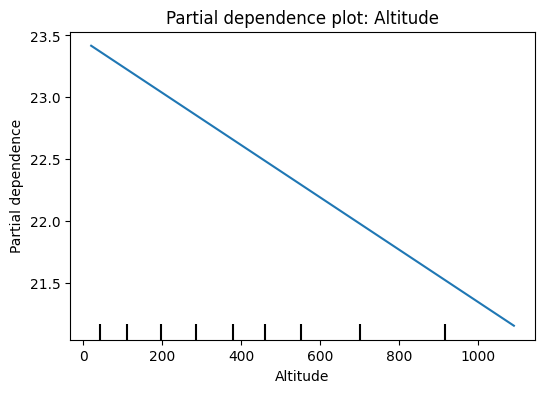

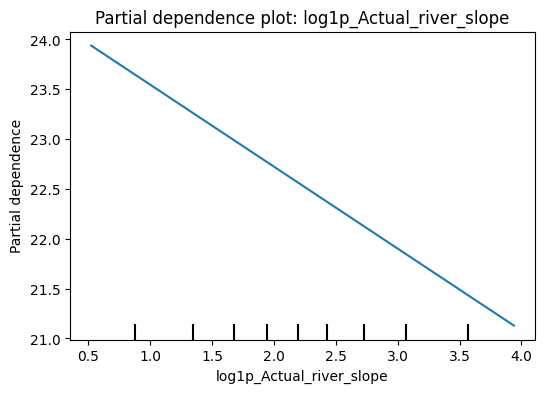

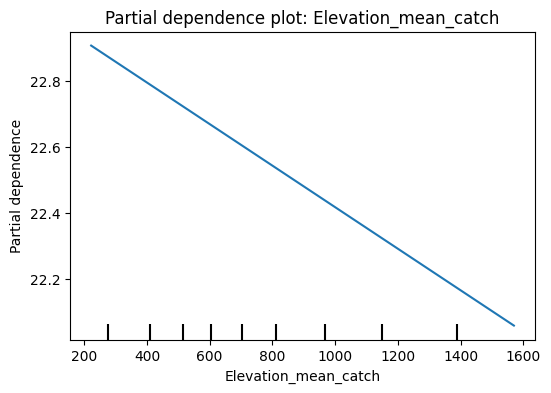

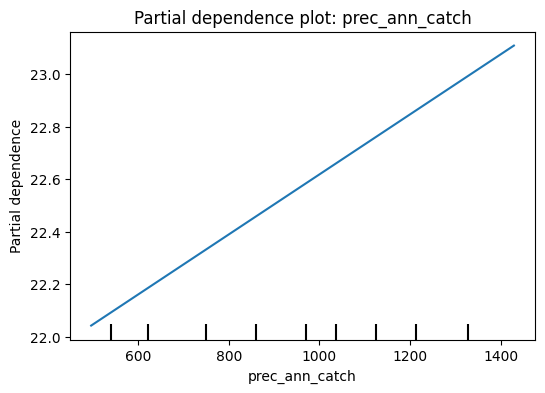

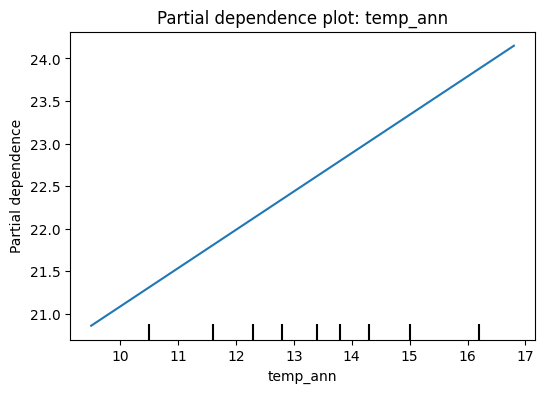

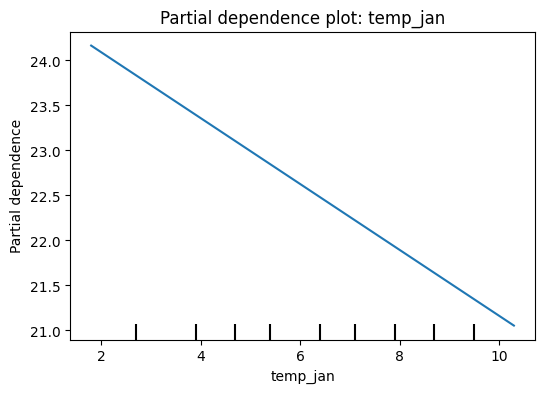

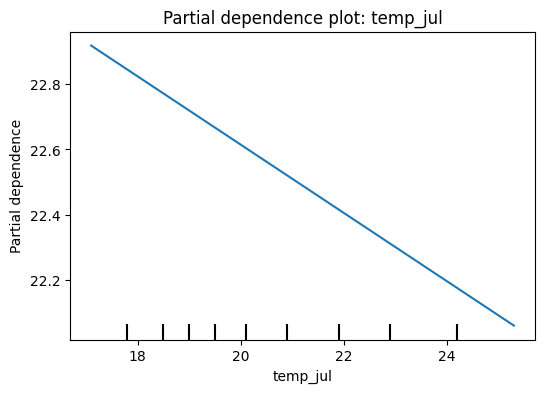

In [46]:
# prompt: Create partial dependence plots for the multiple linear regression model.

X = df_reg[transformed_predictors]
y = df_reg[response]

sklearn_lm = LinearRegression()
sklearn_lm.fit(X, y)

for var in transformed_predictors:
    fig, ax = plt.subplots(figsize=(6, 4))
    PartialDependenceDisplay.from_estimator(
        sklearn_lm,
        X,
        features=[var],
        ax=ax
    )
    plt.title(f"Partial dependence plot: {var}")
    plt.show()

# 7. Check multicollinearity

Environmental predictors can be correlated with each other.

For example, altitude, catchment elevation and temperature may represent related environmental gradients.

I check multicollinearity using:

1. a correlation matrix;
2. Variance Inflation Factor, or VIF.

A common rule of thumb is:

- VIF below 5: acceptable;
- VIF above 5: possible multicollinearity;
- VIF above 10: strong multicollinearity.

,Altitude,log1p_Actual_river_slope,Elevation_mean_catch,prec_ann_catch,temp_ann,temp_jan,temp_jul
Altitude,1.000000,0.332327,0.866247,-0.091476,-0.826067,-0.891908,-0.389132
log1p_Actual_river_slope,0.332327,1.000000,0.322469,0.273985,-0.417988,-0.314286,-0.394975
Elevation_mean_catch,0.866247,0.322469,1.000000,-0.055218,-0.766076,-0.873201,-0.347811
prec_ann_catch,-0.091476,0.273985,-0.055218,1.000000,-0.279067,0.069749,-0.657227
temp_ann,-0.826067,-0.417988,-0.766076,-0.279067,1.000000,0.874951,0.779448
temp_jan,-0.891908,-0.314286,-0.873201,0.069749,0.874951,1.000000,0.405963
temp_jul,-0.389132,-0.394975,-0.347811,-0.657227,0.779448,0.405963,1.000000


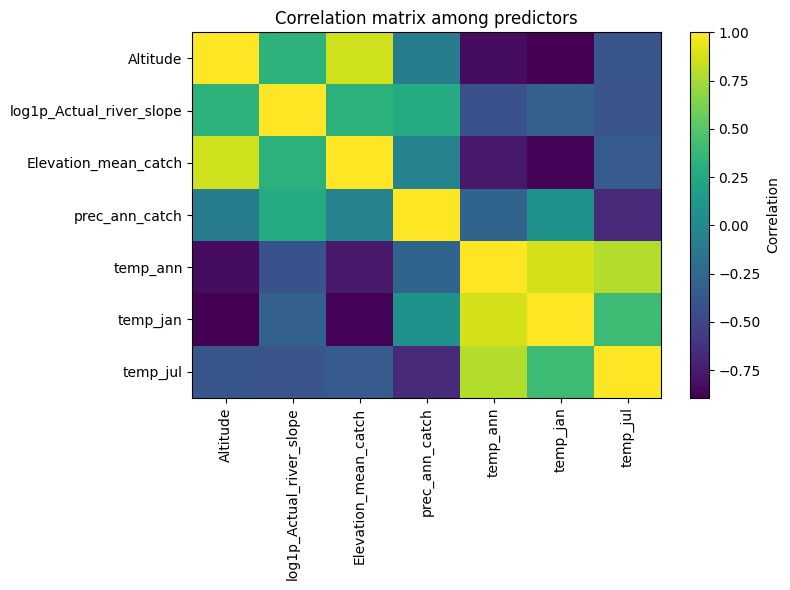

In [47]:
# prompt: Compute and plot the correlation matrix among predictors.

corr_matrix = df_reg[transformed_predictors].corr()

display(corr_matrix)

plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(transformed_predictors)), transformed_predictors, rotation=90)
plt.yticks(range(len(transformed_predictors)), transformed_predictors)
plt.title("Correlation matrix among predictors")
plt.tight_layout()
plt.show()

In [48]:

def compute_vif(data, predictors):
    X_vif = sm.add_constant(data[predictors])
    rows = []
    for i, col in enumerate(X_vif.columns):
        if col != "const":
            rows.append({
                "Predictor": col,
                "VIF": variance_inflation_factor(X_vif.values, i)
            })
    return pd.DataFrame(rows).sort_values("VIF", ascending=False)

vif_df = compute_vif(df_reg, transformed_predictors)
display(vif_df)

,Predictor,VIF
4,temp_ann,73.574659
5,temp_jan,28.855637
6,temp_jul,21.232521
0,Altitude,8.413482
2,Elevation_mean_catch,5.225099
3,prec_ann_catch,2.467029
1,log1p_Actual_river_slope,1.273931


# 8. Parsimonious regression model

A parsimonious model uses fewer predictors and avoids including variables that are strongly redundant.

Here I use an automatic VIF-based procedure:

1. Start with all predictors.
2. Compute VIF.
3. Remove the predictor with the highest VIF if it is above 5.
4. Repeat until all remaining VIF values are below or equal to 5.

This is a transparent rule for reducing multicollinearity.

In [49]:
# prompt: Select a parsimonious predictor set by iteratively removing variables with high VIF.

def select_by_vif(data, predictors, threshold=5.0):
    selected = predictors.copy()
    history = []

    while True:
        vif_current = compute_vif(data, selected)
        max_vif = vif_current["VIF"].max()
        worst_predictor = vif_current.iloc[0]["Predictor"]

        history.append({
            "Step": len(history) + 1,
            "Removed predictor": None if max_vif <= threshold else worst_predictor,
            "Max VIF": max_vif,
            "Predictors kept": selected.copy()
        })

        if max_vif <= threshold or len(selected) <= 2:
            break

        selected.remove(worst_predictor)

    return selected, pd.DataFrame(history)

parsimonious_predictors, vif_selection_history = select_by_vif(
    df_reg,
    transformed_predictors,
    threshold=5.0
)

print("Predictors kept in the parsimonious model:")
print(parsimonious_predictors)

print("\nVIF selection history:")
display(vif_selection_history)

print("\nFinal VIF values:")
display(compute_vif(df_reg, parsimonious_predictors))

Predictors kept in the parsimonious model:
['Altitude', 'log1p_Actual_river_slope', 'Elevation_mean_catch', 'prec_ann_catch', 'temp_jul']

VIF selection history:


,Step,Removed predictor,Max VIF,Predictors kept
0,1,temp_ann,73.574659,"[Altitude, log1p_Actual_river_slope, Elevation..."
1,2,temp_jan,6.401751,"[Altitude, log1p_Actual_river_slope, Elevation..."
2,3,None,4.702844,"[Altitude, log1p_Actual_river_slope, Elevation..."



Final VIF values:


,Predictor,VIF
0,Altitude,4.702844
2,Elevation_mean_catch,4.033354
4,temp_jul,2.772046
3,prec_ann_catch,2.404347
1,log1p_Actual_river_slope,1.273476


In [50]:

formula_parsimonious = response + " ~ " + " + ".join([f"Q('{v}')" for v in parsimonious_predictors])

parsimonious_model = smf.ols(formula_parsimonious, data=df_reg).fit()

print(parsimonious_model.summary())

                            OLS Regression Results                            
Dep. Variable:       species_richness   R-squared:                       0.151
Model:                            OLS   Adj. R-squared:                  0.150
Method:                 Least Squares   F-statistic:                     170.6
Date:                Fri, 15 May 2026   Prob (F-statistic):          1.42e-167
Time:                        20:30:55   Log-Likelihood:                -12434.
No. Observations:                4819   AIC:                         2.488e+04
Df Residuals:                    4813   BIC:                         2.492e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

In [51]:

model_comparison = pd.DataFrame({
    "Model": ["Full multiple model", "Parsimonious model"],
    "Number of predictors": [len(transformed_predictors), len(parsimonious_predictors)],
    "R_squared": [multiple_model.rsquared, parsimonious_model.rsquared],
    "Adjusted_R_squared": [multiple_model.rsquared_adj, parsimonious_model.rsquared_adj],
    "F_statistic": [multiple_model.fvalue, parsimonious_model.fvalue],
    "F_pvalue": [multiple_model.f_pvalue, parsimonious_model.f_pvalue],
    "AIC": [multiple_model.aic, parsimonious_model.aic],
    "BIC": [multiple_model.bic, parsimonious_model.bic]
})

display(model_comparison)

,Model,Number of predictors,R_squared,Adjusted_R_squared,F_statistic,F_pvalue,AIC,BIC
0,Full multiple model,7,0.154112,0.152882,125.216568,1.135175e-169,24864.411926,24916.254500
1,Parsimonious model,5,0.150577,0.149695,170.639954,1.424957e-167,24880.509869,24919.391799


In [52]:

full_coefs = multiple_model.params.rename("Full_model_coefficient")
parsimonious_coefs = parsimonious_model.params.rename("Parsimonious_model_coefficient")

coef_model_comparison = pd.concat([full_coefs, parsimonious_coefs], axis=1)
display(coef_model_comparison)

,Full_model_coefficient,Parsimonious_model_coefficient
Intercept,23.140557,23.167543
Q('Altitude'),-0.002114,-0.002011
Q('log1p_Actual_river_slope'),-0.822365,-0.826529
Q('Elevation_mean_catch'),-0.000629,-0.000125
Q('prec_ann_catch'),0.001143,0.000987
Q('temp_ann'),0.450818,NaN
Q('temp_jan'),-0.366022,NaN
Q('temp_jul'),-0.104516,0.060235


# 9. Final interpretation template

The simple regressions show the isolated relationship between species richness and each environmental predictor.

The multiple regression coefficients can differ from the simple regression coefficients because the multiple model estimates the effect of each predictor while controlling for the remaining predictors.

If some predictors are strongly correlated, the multiple regression coefficients may become unstable. This is why the correlation matrix and VIF values are important.

After removing highly collinear predictors, the parsimonious model should be easier to interpret. The comparison between the full and parsimonious models should consider:

- R-squared;
- adjusted R-squared;
- F-statistic;
- AIC;
- BIC;
- changes in the coefficients.

A good parsimonious model should keep a reasonable explanatory power while reducing redundancy among predictors.